# Module 2 — GraphRAG Retrieval Layer

**GraphRAG for Supply Chain Risk Intelligence**

---

## What this notebook does

Module 1 gave us a knowledge graph and a FAISS index. This module builds the
**retrieval layer** that sits between a user's question and the LLM generator.

By the end we will have:

1. A **dual retriever** — semantic seed search (FAISS) + K-hop graph traversal
2. **Community detection** — Louvain clustering groups the graph into thematic clusters
3. **Community summarization** — each cluster gets a natural language summary (encoder-decoder)
4. A **GraphRAGPipeline** orchestrator that routes local vs global queries
5. Prompt-ready context blocks for 6 representative SC risk queries
6. A side-by-side comparison: vector RAG vs GraphRAG context quality

## GenAI concepts covered

| Concept | Where |
|---|---|
| **Embeddings** | Query encoding for FAISS seed search (same encoder as Module 1) |
| **Encoder-only** | sentence-transformer encodes the query at retrieval time |
| **Encoder-decoder** | T5/BART summarizes each graph community into natural language |
| **Transformer architecture** | Foundation of all three models above |

---

## 0. Environment Setup

In [1]:
# ── Installs (run once) ───────────────────────────────────────────────────────
# !pip install python-louvain transformers networkx sentence-transformers faiss-cpu

In [4]:
import sys
import json
import pickle
from pathlib import Path
from pprint import pprint

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Project imports ───────────────────────────────────────────────────────────
from src.graph.schema         import NODE_ATTR_TYPE, EDGE_ATTR_RELATION, EDGE_ATTR_WEIGHT
from src.embeddings.encoder   import NodeEncoder
from src.retrieval.retriever  import SubgraphRetriever
from src.retrieval.community  import CommunitySummarizer
from src.retrieval.pipeline   import GraphRAGPipeline
from src.utils.visualization  import plot_graph

DATA_PROCESSED = Path("../data/processed")
OUTPUTS        = Path("../outputs")
(OUTPUTS / "retrieval").mkdir(parents=True, exist_ok=True)

print("✓ Environment ready")

✓ Environment ready


---

## Step 1 — Load Module 1 Outputs

Everything Module 2 needs was persisted by Module 1:
- `graph.gpickle` — the NetworkX DiGraph with typed nodes and weighted edges
- `faiss_index.bin` — the FAISS index of node embeddings

No recomputation needed.

In [6]:
import pickle
# ── Load graph ────────────────────────────────────────────────────────────────
graph_path = DATA_PROCESSED / "graph.gpickle"

if not graph_path.exists():
    raise FileNotFoundError(
        "graph.gpickle not found. Run notebook 01 first to build it."
    )

#G = nx.read_gpickle(str(graph_path))

with open(graph_path, 'rb') as f:
    G = pickle.load(f)

print(f"✓ Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ── Load encoder + FAISS index ────────────────────────────────────────────────
faiss_path = DATA_PROCESSED / "faiss_index.bin"

encoder = NodeEncoder(model_name="all-MiniLM-L6-v2")

if faiss_path.exists():
    encoder.load_index(faiss_path)
    # Re-attach embeddings to graph nodes from the index
    print(f"✓ FAISS index loaded: {encoder._index.ntotal} vectors")
else:
    print("FAISS index not found — re-encoding graph nodes...")
    encoder.encode_graph(G)
    encoder.save_index(faiss_path)

print(f"  Embedding dimension: {encoder.dim}")

✓ Graph loaded: 53 nodes, 60 edges
[Encoder] Loading model: all-MiniLM-L6-v2
[Encoder] Loaded index: 53 vectors from ../data/processed/faiss_index.bin
✓ FAISS index loaded: 53 vectors
  Embedding dimension: 384


---

## Step 2 — Semantic Seed Search (Stage A)

The first half of dual retrieval: encode the query with the same
sentence-transformer used in Module 1 and find the most similar graph nodes.

These become the **entry points** into the graph for Stage B traversal.

In [7]:
# ── Initialize the retriever ──────────────────────────────────────────────────
retriever = SubgraphRetriever(
    graph=G,
    encoder=encoder,
    seed_k=5,         # top-5 FAISS results as seed nodes
    hop_radius=2,     # expand 2 hops from each seed
    max_nodes=40,     # cap subgraph at 40 nodes
)

print("✓ SubgraphRetriever initialized")

✓ SubgraphRetriever initialized


In [8]:
# ── Run semantic seed search for a sample query ───────────────────────────────
sample_query = "Which semiconductor suppliers are at risk from the Taiwan earthquake?"

seed_nodes, semantic_scores = retriever._semantic_seeds(sample_query)

print(f"Query: {sample_query!r}")
print(f"\nTop seed nodes (FAISS semantic search):")
print("-" * 55)
for node, score in sorted(semantic_scores.items(), key=lambda x: -x[1]):
    etype = G.nodes[node].get(NODE_ATTR_TYPE, "?")
    bar   = "█" * int(score * 20)
    print(f"  {node:30s} [{etype:15s}] sim={score:.4f} {bar}")

Query: 'Which semiconductor suppliers are at risk from the Taiwan earthquake?'

Top seed nodes (FAISS semantic search):
-------------------------------------------------------
  Taiwan Semiconductor Manufacturing [Supplier       ] sim=0.6727 █████████████
  the Taiwan Earthquake          [Region         ] sim=0.6328 ████████████
  Taiwan                         [Region         ] sim=0.4219 ████████
  The Shanghai Lockdown          [DisruptionEvent] sim=0.4160 ████████
  Panasonic Energy               [Manufacturer   ] sim=0.4011 ████████


---

## Step 3 — K-Hop Graph Expansion (Stage B)

From each seed, expand outward K hops via `nx.ego_graph`.
This is what turns a list of relevant-sounding nodes into a full
relational context — pulling in the suppliers those nodes depend on,
the ports they ship through, the regions they're located in, etc.

In [9]:
# ── Graph expansion from seed nodes ──────────────────────────────────────────
candidate_nodes = retriever._graph_expansion(seed_nodes)

print(f"Seed nodes         : {len(seed_nodes)}")
print(f"Candidates (2-hop) : {len(candidate_nodes)}")
print(f"\nExpanded candidate nodes:")
for node in sorted(candidate_nodes):
    etype = G.nodes[node].get(NODE_ATTR_TYPE, "?")
    is_seed = " ← seed" if node in seed_nodes else ""
    print(f"  {node:35s} [{etype}]{is_seed}")

Seed nodes         : 5
Candidates (2-hop) : 31

Expanded candidate nodes:
  AMD                                 [Part]
  ASML                                [Supplier]
  Apple                               [Manufacturer]
  BMW                                 [Part]
  CATL                                [Part]
  China                               [Region]
  Europe                              [Region]
  European                            [Region]
  Foxconn                             [Region]
  Gigafactory Nevada                  [Region]
  GlobalFoundries                     [Part]
  Japan                               [Region]
  Jiangxi                             [Region]
  LG Energy                           [Part]
  NVIDIA                              [Part]
  Netherlands                         [Region]
  Panasonic                           [Part]
  Panasonic Energy                    [Manufacturer] ← seed
  South Korea                         [Region]
  TSMC                    

---

## Step 4 — Fusion Scoring

Every candidate node gets a combined score:

```
score = 0.6 × semantic_score  +  0.4 × structural_score
```

- `semantic_score` — how close this node is to the query in embedding space
  (1.0 for seeds, decays by 50% per hop for expanded nodes)
- `structural_score` — normalized degree centrality; hub nodes (major ports,
  tier-1 suppliers) rank higher because they're more important in the SC graph

This fusion is what makes GraphRAG smarter than pure vector search:
a critical hub that isn't semantically close to the query still gets
included because of its structural importance.

In [10]:
# ── Score all candidate nodes ─────────────────────────────────────────────────
node_scores = retriever._score_nodes(candidate_nodes, seed_nodes, semantic_scores)

# Sort and display
print(f"Node fusion scores (semantic 60% + structural 40%):")
print("-" * 65)
print(f"  {'Node':35s} {'Type':15s} {'Score':8s} {'Bar'}")
print(f"  {'-'*35} {'-'*15} {'-'*8}")

for node, score in sorted(node_scores.items(), key=lambda x: -x[1]):
    etype = G.nodes[node].get(NODE_ATTR_TYPE, "?")
    bar   = "█" * int(score * 25)
    seed_tag = " *" if node in seed_nodes else ""
    print(f"  {(node+seed_tag):35s} {etype:15s} {score:.4f}   {bar}")

print(f"\n  * = direct FAISS seed node")

Node fusion scores (semantic 60% + structural 40%):
-----------------------------------------------------------------
  Node                                Type            Score    Bar
  ----------------------------------- --------------- --------
  Taiwan Semiconductor Manufacturing * Supplier        0.4113   ██████████
  TSMC                                DisruptionEvent 0.4000   ██████████
  the Taiwan Earthquake *             Region          0.3874   █████████
  Tesla                               Manufacturer    0.3692   █████████
  Apple                               Manufacturer    0.3615   █████████
  China                               Region          0.3385   ████████
  the Port of Shanghai                Port            0.3308   ████████
  CATL                                Part            0.3308   ████████
  Foxconn                             Region          0.3231   ████████
  iPhones                             Manufacturer    0.3231   ████████
  ASML                  

---

## Step 5 — Full Retrieval: End-to-End

Now we run the complete `retrieve()` call which chains all three stages
and returns a `RetrievedSubgraph` with the serialized prompt context.

In [11]:
# ── Full retrieval ────────────────────────────────────────────────────────────
result = retriever.retrieve(sample_query)

print(f"Retrieval stats:")
print(f"  Seed nodes              : {result.stats['seed_nodes']}")
print(f"  Candidates before trim  : {result.stats['candidates_before_trim']}")
print(f"  Final subgraph nodes    : {result.stats['subgraph_nodes']}")
print(f"  Final subgraph edges    : {result.stats['subgraph_edges']}")

print(f"\n{'='*60}")
print("SERIALIZED SUBGRAPH (LLM prompt context):")
print('='*60)
print(result.serialized)

Retrieval stats:
  Seed nodes              : 5
  Candidates before trim  : 31
  Final subgraph nodes    : 31
  Final subgraph edges    : 52

SERIALIZED SUBGRAPH (LLM prompt context):
=== Supply Chain Subgraph Context ===
Query: Which semiconductor suppliers are at risk from the Taiwan earthquake?
Nodes: 31  |  Edges: 52

[NODE] Taiwan Semiconductor Manufacturing | Type: Supplier | Relevance: 0.41
  → depends_on ASML (weight=1.00) [CRITICAL - no alternative]

[NODE] TSMC | Type: DisruptionEvent | Relevance: 0.40
  → located_in Taiwan (weight=1.00) [CRITICAL - no alternative]
  → supplies Apple (weight=1.00) [CRITICAL - no alternative]
  → supplies NVIDIA (weight=1.00) [CRITICAL - no alternative]
  → supplies AMD (weight=1.00) [CRITICAL - no alternative]
  → ships_through the Port of Kaohsiung (weight=1.00) [CRITICAL - no alternative]
  → ships_through the United States (weight=1.00) [CRITICAL - no alternative]
  → ships_through Europe (weight=1.00) [CRITICAL - no alternative]
  → affect

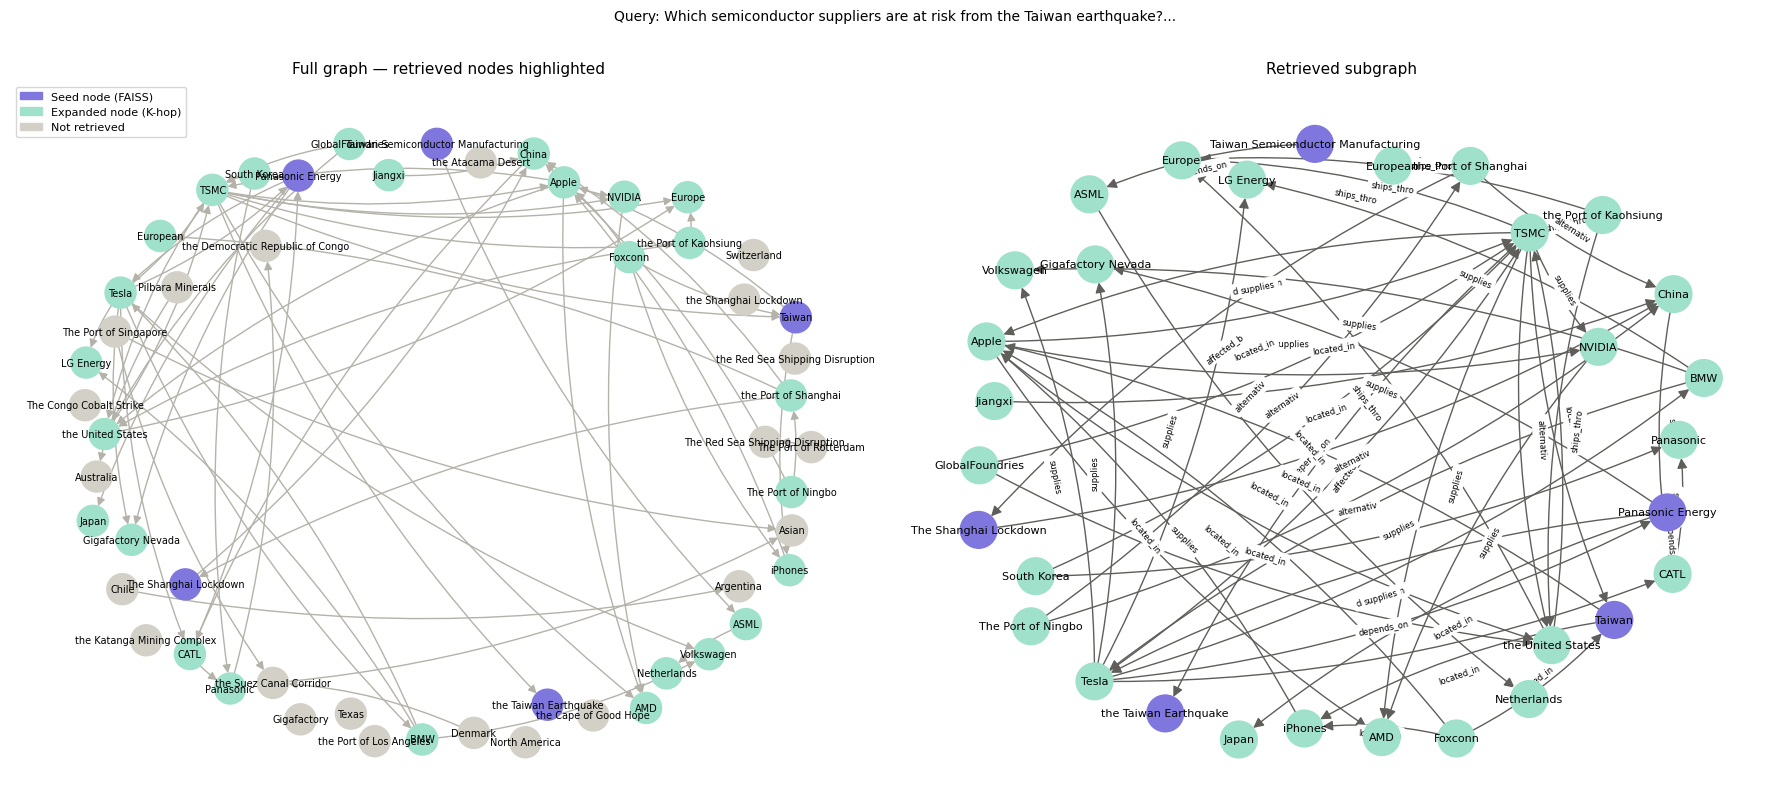

✓ Visualization saved


In [12]:
# ── Visualize the retrieved subgraph ──────────────────────────────────────────
# Color nodes by their retrieval score (darker = more relevant)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: full graph with retrieved nodes highlighted
node_colors_full = []
for node in G.nodes():
    if node in result.seed_nodes:
        node_colors_full.append("#7F77DD")   # purple = seed
    elif node in result.node_scores:
        node_colors_full.append("#9FE1CB")   # teal = expanded
    else:
        node_colors_full.append("#D3D1C7")   # gray = not retrieved

pos = nx.spring_layout(G, seed=42, k=2.5)
nx.draw(G, pos, ax=axes[0],
        node_color=node_colors_full, node_size=500,
        with_labels=True, font_size=7,
        arrows=True, arrowsize=12, edge_color="#B4B2A9",
        connectionstyle="arc3,rad=0.1")
axes[0].set_title("Full graph — retrieved nodes highlighted", fontsize=11)

legend_handles = [
    mpatches.Patch(color="#7F77DD", label="Seed node (FAISS)"),
    mpatches.Patch(color="#9FE1CB", label="Expanded node (K-hop)"),
    mpatches.Patch(color="#D3D1C7", label="Not retrieved"),
]
axes[0].legend(handles=legend_handles, fontsize=8, loc="upper left")

# Right: retrieved subgraph only
sub_G = result.graph
sub_pos = nx.spring_layout(sub_G, seed=42, k=3)
sub_colors = [
    "#7F77DD" if n in result.seed_nodes else "#9FE1CB"
    for n in sub_G.nodes()
]
nx.draw(sub_G, sub_pos, ax=axes[1],
        node_color=sub_colors, node_size=700,
        with_labels=True, font_size=8,
        arrows=True, arrowsize=15, edge_color="#5F5E5A",
        connectionstyle="arc3,rad=0.1")

edge_labels = {
    (u, v): data.get(EDGE_ATTR_RELATION, "")[:10]
    for u, v, data in sub_G.edges(data=True)
}
nx.draw_networkx_edge_labels(sub_G, sub_pos, edge_labels=edge_labels,
                              font_size=6, ax=axes[1])
axes[1].set_title("Retrieved subgraph", fontsize=11)

plt.suptitle(f"Query: {sample_query[:70]}...", fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / "retrieval" / "module2_retrieval_viz.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Visualization saved")

---

## Step 6 — Community Detection (Louvain)

The Louvain algorithm finds groups of nodes that are more densely connected
to each other than to the rest of the graph. In a supply chain graph, these
clusters naturally correspond to:
- Semiconductor cluster (TSMC, ASML, Apple, NVIDIA, AMD)
- Battery/EV cluster (CATL, Panasonic, Glencore, Tesla)
- Logistics/disruption cluster (ports + events)

This addresses the key weakness of local retrieval: **global queries** about
the whole supply chain can't be answered by one subgraph. Pre-computed
community summaries give the LLM a "bird's eye view" of the graph.

In [13]:
# ── Initialize the summarizer ─────────────────────────────────────────────────
# use_llm=False uses rule-based summaries (no GPU needed).
# Set use_llm=True if you have a GPU and want real T5/BART summaries.

summarizer = CommunitySummarizer(
    graph=G,
    use_llm=False,    # set True for encoder-decoder model summaries
)

communities = summarizer.detect_and_summarize()

print(f"\n✓ Detected {len(communities)} communities")
print(f"\nCommunity overview:")
print("-" * 70)
for c in communities:
    print(f"  Community {c.community_id:2d} | {c.dominant_type:15s} | "
          f"{c.size:3d} nodes | {c.internal_edges:3d} internal edges")
    print(f"    Nodes: {', '.join(c.nodes[:6])}"
          + (f" ... +{len(c.nodes)-6} more" if len(c.nodes) > 6 else ""))
    print(f"    Summary: {c.summary[:100]}")
    print()

[Community] Detecting communities (Louvain)...
[Community] Found 24 raw communities
[Community] 9 communities summarized (≥ 2 nodes each)

✓ Detected 9 communities

Community overview:
----------------------------------------------------------------------
  Community  7 | Part            |  10 nodes |  15 internal edges
    Nodes: Panasonic, Tesla, CATL, the Democratic Republic of Congo, Gigafactory Nevada, Japan ... +4 more
    Summary: A part cluster of 10 supply chain entities. Central hub: Tesla. Primary relationship types: depends_

  Community  5 | Manufacturer    |   6 nodes |   9 internal edges
    Nodes: Apple, Foxconn, Taiwan, NVIDIA, AMD, iPhones
    Summary: A manufacturer cluster of 6 supply chain entities. Central hub: Apple. Primary relationship types: l

  Community  9 | Region          |   6 nodes |  10 internal edges
    Nodes: TSMC, the Taiwan Earthquake, the United States, Europe, GlobalFoundries, the Port of Kaohsiung
    Summary: A region cluster of 6 supply chain

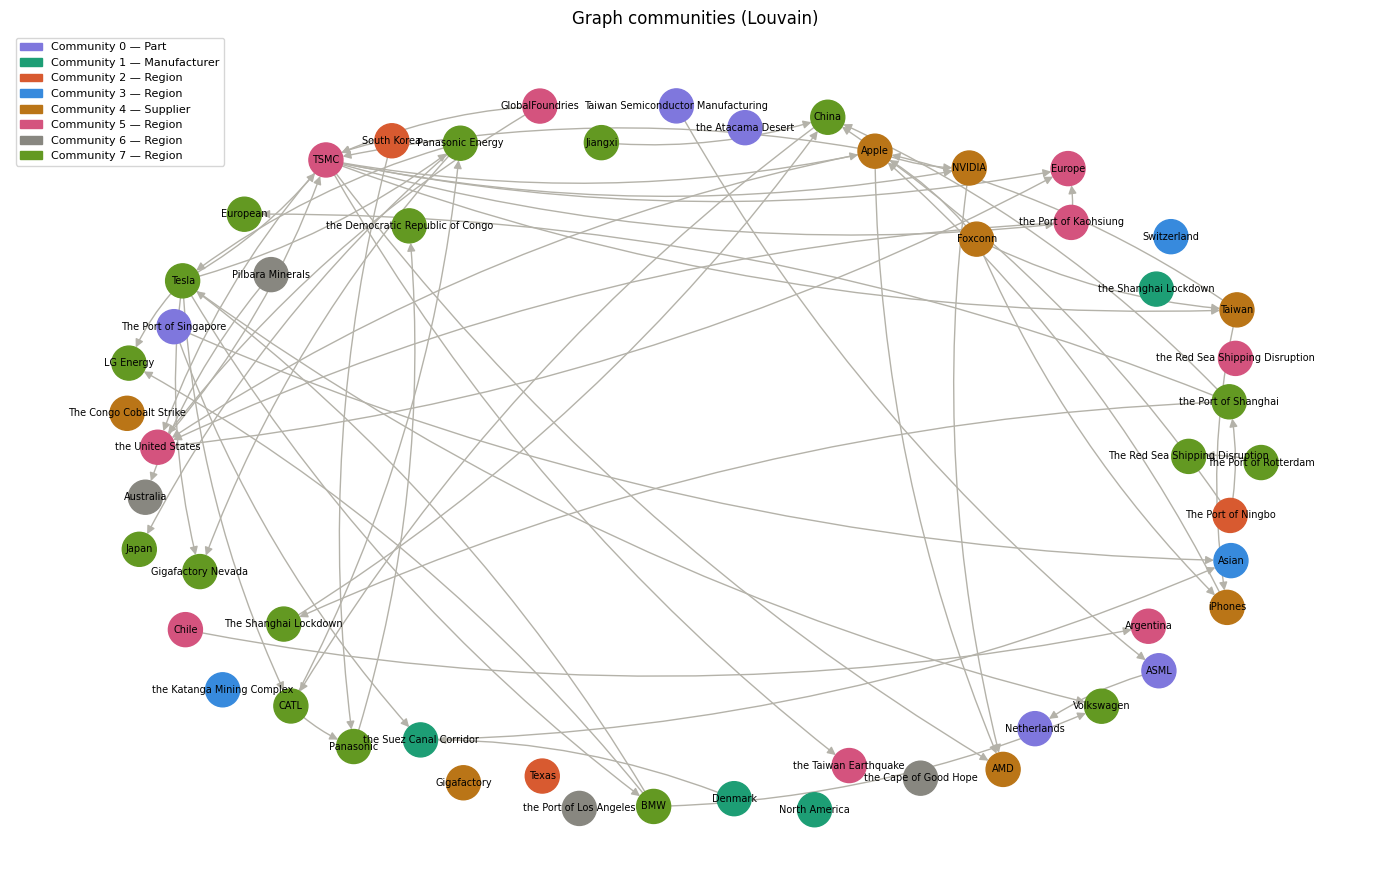

✓ Community visualization saved


In [14]:
# ── Visualize communities ─────────────────────────────────────────────────────
# Each community gets a distinct color. This should roughly align with
# the SC sub-domains we expect (semiconductor, battery, logistics).

try:
    import community as community_louvain
    partition = community_louvain.best_partition(G.to_undirected())
    n_communities = max(partition.values()) + 1

    COMMUNITY_COLORS = [
        "#7F77DD", "#1D9E75", "#D85A30", "#378ADD",
        "#BA7517", "#D4537E", "#888780", "#639922",
    ]

    node_comm_colors = [
        COMMUNITY_COLORS[partition.get(n, 0) % len(COMMUNITY_COLORS)]
        for n in G.nodes()
    ]

    fig, ax = plt.subplots(figsize=(14, 9))
    pos = nx.spring_layout(G, seed=42, k=2.5)
    nx.draw(G, pos, ax=ax,
            node_color=node_comm_colors, node_size=600,
            with_labels=True, font_size=7,
            edge_color="#B4B2A9", arrows=True, arrowsize=12,
            connectionstyle="arc3,rad=0.1")

    legend_handles = [
        mpatches.Patch(
            color=COMMUNITY_COLORS[i % len(COMMUNITY_COLORS)],
            label=f"Community {i} — {communities[i].dominant_type if i < len(communities) else '?'}"
        )
        for i in range(min(n_communities, len(COMMUNITY_COLORS)))
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc="upper left")
    ax.set_title("Graph communities (Louvain)", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUTS / "retrieval" / "module2_communities.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Community visualization saved")
except ImportError:
    print("python-louvain not installed — skipping community visualization.")
    print("Run: pip install python-louvain")

---

## Step 7 — Community Summarization (Encoder-Decoder)

Each community description is fed to a **T5/BART encoder-decoder model**
to generate a concise natural language summary.

This is the encoder-decoder concept from the course:
- The **encoder** reads the full community description (entities + relationships)
- The **decoder** auto-regressively generates a compressed summary

With `use_llm=False` (no GPU), the rule-based fallback produces summaries
that are still useful. Switch to `use_llm=True` to see real T5 output.

In [15]:
# ── Show what the community text looks like before summarization ──────────────
# This is the input the encoder-decoder model receives.

sample_community = communities[0]
community_text = summarizer._community_to_text(sample_community)

print("INPUT to T5/BART encoder:")
print("-" * 60)
print(community_text)
print()
print("OUTPUT (summary):")
print("-" * 60)
print(sample_community.summary)

INPUT to T5/BART encoder:
------------------------------------------------------------
Supply chain community: Part cluster with 10 entities. Entities: Panasonic (Part), Tesla (Manufacturer), CATL (Part), the Democratic Republic of Congo (Region), Gigafactory Nevada (Region), Japan (Region), Panasonic Energy (Manufacturer), Volkswagen (Part), LG Energy (Part), BMW (Part). Relationships: Panasonic supplies the Democratic Republic of Congo. Tesla supplies BMW. Tesla supplies Volkswagen. Tesla supplies Gigafactory Nevada. Tesla supplies LG Energy. Tesla depends_on CATL. Tesla depends_on Panasonic Energy. CATL supplies Panasonic. CATL depends_on Panasonic Energy. Panasonic Energy located_in Japan. Panasonic Energy supplies Tesla. Panasonic Energy supplies Gigafactory Nevada. BMW supplies Volkswagen. BMW supplies Tesla. BMW supplies LG Energy.

OUTPUT (summary):
------------------------------------------------------------
A part cluster of 10 supply chain entities. Central hub: Tesla. Prima

In [16]:
# ── (Optional) Run with real T5/BART model ────────────────────────────────────
# Uncomment to test with the actual encoder-decoder model.
# Requires: pip install transformers torch
# First run will download ~1.6GB model weights.

# summarizer_llm = CommunitySummarizer(
#     graph=G,
#     model_name="sshleifer/distilbart-cnn-12-6",  # smaller, faster
#     use_llm=True,
# )
# communities_llm = summarizer_llm.detect_and_summarize()
# print("T5/BART summary for community 0:")
# print(communities_llm[0].summary)

In [17]:
# ── Find relevant communities for a global query ──────────────────────────────
global_query = "What is our overall exposure to East Asian geopolitical risk?"

relevant_comms = summarizer.find_relevant_communities(global_query, top_k=3)

print(f"Global query: {global_query!r}")
print(f"\nMost relevant communities:")
print("-" * 60)
for c in relevant_comms:
    print(f"  Community {c.community_id} ({c.dominant_type}, {c.size} nodes)")
    print(f"  → {c.summary}")
    print()

print("\nFormatted for LLM prompt:")
print("=" * 60)
print(summarizer.format_for_prompt(relevant_comms))

Global query: 'What is our overall exposure to East Asian geopolitical risk?'

Most relevant communities:
------------------------------------------------------------
  Community 7 (Part, 10 nodes)
  → A part cluster of 10 supply chain entities. Central hub: Tesla. Primary relationship types: depends_on, located_in, supplies. Contains 15 internal connections.

  Community 9 (Region, 6 nodes)
  → A region cluster of 6 supply chain entities. Central hub: TSMC. Primary relationship types: affected_by, alternative_to, located_in, ships_through. Contains 10 internal connections.

  Community 16 (Region, 5 nodes)
  → A region cluster of 5 supply chain entities. Central hub: China. Primary relationship types: affected_by, alternative_to, located_in, ships_through. Contains 5 internal connections.


Formatted for LLM prompt:
=== Community Summaries (global context) ===

[Community 7 — Part cluster (10 nodes)]
A part cluster of 10 supply chain entities. Central hub: Tesla. Primary relationship 

---

## Step 8 — GraphRAGPipeline: End-to-End Orchestration

The `GraphRAGPipeline` wraps both the retriever and the summarizer and
auto-routes queries to the right context blend:
- **Local query** → subgraph context only
- **Global query** → community summaries + subgraph context

In [18]:
# ── Initialize and build the full pipeline ────────────────────────────────────
pipeline = GraphRAGPipeline(
    graph=G,
    encoder=encoder,
    seed_k=5,
    hop_radius=2,
    max_nodes=40,
    use_llm_summaries=False,
)

communities_path = DATA_PROCESSED / "communities.json"
pipeline.build_communities(save_path=str(communities_path))

print("✓ Pipeline ready")
print()
print(pipeline.community_overview())

[Community] Detecting communities (Louvain)...
[Community] Found 24 raw communities
[Community] 9 communities summarized (≥ 2 nodes each)
[Community] Communities saved → ../data/processed/communities.json
✓ Pipeline ready

Communities detected: 9

  Community  7 | Part            |  10 nodes |  15 internal edges
    → A part cluster of 10 supply chain entities. Central hub: Tesla. Primary relationship types...
  Community 20 | Manufacturer    |   6 nodes |   9 internal edges
    → A manufacturer cluster of 6 supply chain entities. Central hub: Apple. Primary relationshi...
  Community  5 | Region          |   6 nodes |  10 internal edges
    → A region cluster of 6 supply chain entities. Central hub: TSMC. Primary relationship types...
  Community 16 | Region          |   5 nodes |   5 internal edges
    → A region cluster of 5 supply chain entities. Central hub: China. Primary relationship type...
  Community  0 | Supplier        |   3 nodes |   2 internal edges
    → A supplier clust

In [19]:
# ── Run representative queries ────────────────────────────────────────────────
# These six queries cover the key SC risk scenarios the project targets.
# They also serve as the evaluation benchmark for Module 5.

BENCHMARK_QUERIES = [
    # Local — multi-hop dependency queries
    ("local",  "Which suppliers does Tesla depend on for battery cells?"),
    ("local",  "Is TSMC exposed to the Taiwan earthquake?"),
    ("local",  "What would happen to Apple if the Port of Shanghai closes?"),

    # Local — alternative supplier queries
    ("local",  "Are there alternative suppliers to TSMC for chip manufacturing?"),

    # Global — broad risk queries
    ("global", "What is our overall exposure to East Asian geopolitical risk?"),
    ("global", "Which regions create the most supply concentration risk?"),
]

results = []
for expected_type, query in BENCHMARK_QUERIES:
    r = pipeline.query(query)
    results.append(r)
    detected = r.query_type
    match = "✓" if detected == expected_type else "✗"
    print(f"{match} [{detected:6s}] {query[:65]}")
    print(f"       → {r.subgraph_result.stats['subgraph_nodes']} nodes, "
          f"{r.subgraph_result.stats['subgraph_edges']} edges, "
          f"{len(r.communities)} communities")
    print()

✓ [local ] Which suppliers does Tesla depend on for battery cells?
       → 26 nodes, 45 edges, 0 communities

✓ [local ] Is TSMC exposed to the Taiwan earthquake?
       → 30 nodes, 51 edges, 0 communities

✓ [local ] What would happen to Apple if the Port of Shanghai closes?
       → 13 nodes, 12 edges, 0 communities

✓ [local ] Are there alternative suppliers to TSMC for chip manufacturing?
       → 26 nodes, 45 edges, 0 communities

✓ [global] What is our overall exposure to East Asian geopolitical risk?
       → 28 nodes, 46 edges, 3 communities

✓ [global] Which regions create the most supply concentration risk?
       → 30 nodes, 47 edges, 3 communities



In [20]:
# ── Inspect full prompt context for query 1 ───────────────────────────────────
# This is exactly what will be injected into the LLM prompt in Module 4.

print(results[0].prompt_context)

You are a supply chain risk analyst with access to a knowledge graph.
Use ONLY the graph context below to answer. Cite specific entity names and relationship paths in your answer.
If a fact is not in the context, say so explicitly.


=== Supply Chain Subgraph Context ===
Query: Which suppliers does Tesla depend on for battery cells?
Nodes: 26  |  Edges: 45

[NODE] Tesla | Type: Manufacturer | Relevance: 0.47
  → supplies BMW (weight=1.00) [CRITICAL - no alternative]
  → supplies Volkswagen (weight=1.00) [CRITICAL - no alternative]
  → supplies Gigafactory Nevada (weight=1.00) [CRITICAL - no alternative]
  → supplies LG Energy (weight=1.00) [CRITICAL - no alternative]
  → depends_on TSMC (weight=1.00) [CRITICAL - no alternative]
  → depends_on CATL (weight=1.00) [CRITICAL - no alternative]
  → depends_on Panasonic Energy (weight=1.00) [CRITICAL - no alternative]
  ← supplies Panasonic Energy
  ← supplies BMW

[NODE] TSMC | Type: DisruptionEvent | Relevance: 0.40
  → located_in Taiwan (w

In [21]:
# ── Inspect full prompt context for the global query ─────────────────────────
# Note how community summaries are prepended before the local subgraph.

print(results[4].prompt_context)

You are a supply chain risk analyst with access to a knowledge graph.
Use ONLY the graph context below to answer. Cite specific entity names and relationship paths in your answer.
If a fact is not in the context, say so explicitly.


=== Community Summaries (global context) ===

[Community 7 — Part cluster (10 nodes)]
A part cluster of 10 supply chain entities. Central hub: Tesla. Primary relationship types: depends_on, located_in, supplies. Contains 15 internal connections.
Key entities: Panasonic, Tesla, CATL, the Democratic Republic of Congo, Gigafactory Nevada, Japan, Panasonic Energy, Volkswagen ... (+2 more)

[Community 5 — Region cluster (6 nodes)]
A region cluster of 6 supply chain entities. Central hub: TSMC. Primary relationship types: affected_by, alternative_to, located_in, ships_through. Contains 10 internal connections.
Key entities: TSMC, the Taiwan Earthquake, the United States, Europe, GlobalFoundries, the Port of Kaohsiung

[Community 16 — Region cluster (5 nodes)]
A 

---

## Step 9 — Vector RAG vs GraphRAG Comparison

This is the core ablation that justifies GraphRAG over vanilla RAG.

Vector RAG simply returns the top-K most similar nodes by embedding —
no graph traversal, no community context. We compare the two retrieval
methods on the multi-hop query where GraphRAG has the biggest advantage.

In [22]:
# ── Simulate vector RAG ───────────────────────────────────────────────────────
# Vector RAG = FAISS top-K only, no graph expansion, no community context.

def vector_rag_context(query: str, k: int = 8) -> str:
    """Simulate vanilla vector RAG: top-K nodes by embedding similarity only."""
    results = encoder.search(query, k=k)
    lines   = [f"=== Vector RAG Context ===\nQuery: {query}\n"]
    for node, score in results:
        if node not in G:
            continue
        etype = G.nodes[node].get(NODE_ATTR_TYPE, "?")
        lines.append(f"[NODE] {node} | Type: {etype} | Sim: {score:.3f}")
    return "\n".join(lines)


# Compare on the multi-hop query
comparison_query = "Which suppliers does Tesla depend on for battery cells?"

vector_context = vector_rag_context(comparison_query)
graphrag_result = pipeline.query(comparison_query)

print("VECTOR RAG CONTEXT")
print("=" * 55)
print(vector_context)
print()
print("GRAPHRAG CONTEXT (first 60 lines)")
print("=" * 55)
ctx_lines = graphrag_result.prompt_context.split("\n")
print("\n".join(ctx_lines[:60]))

VECTOR RAG CONTEXT
=== Vector RAG Context ===
Query: Which suppliers does Tesla depend on for battery cells?

[NODE] Tesla | Type: Manufacturer | Sim: 0.674
[NODE] Panasonic Energy | Type: Manufacturer | Sim: 0.462
[NODE] iPhones | Type: Manufacturer | Sim: 0.426
[NODE] Apple | Type: Manufacturer | Sim: 0.337
[NODE] Taiwan Semiconductor Manufacturing | Type: Supplier | Sim: 0.321
[NODE] BMW | Type: Part | Sim: 0.301
[NODE] Volkswagen | Type: Part | Sim: 0.246
[NODE] LG Energy | Type: Part | Sim: 0.226

GRAPHRAG CONTEXT (first 60 lines)
You are a supply chain risk analyst with access to a knowledge graph.
Use ONLY the graph context below to answer. Cite specific entity names and relationship paths in your answer.
If a fact is not in the context, say so explicitly.


=== Supply Chain Subgraph Context ===
Query: Which suppliers does Tesla depend on for battery cells?
Nodes: 26  |  Edges: 45

[NODE] Tesla | Type: Manufacturer | Relevance: 0.47
  → supplies BMW (weight=1.00) [CRITICAL - no 

In [23]:
# ── Quantitative context comparison ──────────────────────────────────────────

def count_sc_entities_in_context(text: str) -> dict:
    """Count how many SC-relevant entity types appear in a context string."""
    entity_types = ["Supplier", "Manufacturer", "Part", "Port",
                    "Region", "DisruptionEvent", "Customer"]
    return {et: text.count(et) for et in entity_types}

v_counts = count_sc_entities_in_context(vector_context)
g_counts = count_sc_entities_in_context(graphrag_result.prompt_context)

# Count multi-hop relationships (→ in serialized output)
v_relations = vector_context.count("→")
g_relations = graphrag_result.prompt_context.count("→")
g_critical  = graphrag_result.prompt_context.count("CRITICAL")

print(f"Context quality comparison — '{comparison_query[:45]}...'")
print("-" * 55)
print(f"{'Metric':40s} {'VectorRAG':>10} {'GraphRAG':>10}")
print(f"  {'Relationship edges in context':38s} {v_relations:>10} {g_relations:>10}")
print(f"  {'Critical dependency alerts':38s} {0:>10} {g_critical:>10}")
print(f"  {'Total characters':38s} {len(vector_context):>10} {len(graphrag_result.prompt_context):>10}")
print()
print("Entity type coverage:")
for et in ["Supplier", "Manufacturer", "Port", "Region", "DisruptionEvent"]:
    print(f"  {et:38s} {v_counts[et]:>10} {g_counts[et]:>10}")

Context quality comparison — 'Which suppliers does Tesla depend on for batt...'
-------------------------------------------------------
Metric                                    VectorRAG   GraphRAG
  Relationship edges in context                   0         45
  Critical dependency alerts                      0         42
  Total characters                              487       5795

Entity type coverage:
  Supplier                                        1          2
  Manufacturer                                    4          4
  Port                                            0          5
  Region                                          0         10
  DisruptionEvent                                 0          1


---

## Step 10 — Save Outputs for Module 3

In [24]:
# ── Persist everything Module 3 needs ────────────────────────────────────────
import pickle

# Save benchmark query results as pickle (carries full subgraph objects)
results_path = DATA_PROCESSED / "retrieval_results.pkl"
with open(results_path, "wb") as f:
    pickle.dump(results, f)

# Save communities (already saved above, confirming)
print("\n✓ Module 2 outputs saved:")
for f in sorted(DATA_PROCESSED.iterdir()):
    print(f"  {f.name:40s} {f.stat().st_size:>10,} bytes")


✓ Module 2 outputs saved:
  communities.json                              3,531 bytes
  entities.json                                10,222 bytes
  faiss_index.bin                              81,453 bytes
  faiss_index.bin.names                           930 bytes
  graph.gpickle                                93,580 bytes
  retrieval_results.pkl                       159,486 bytes
  triples.json                                 12,497 bytes


---

## Module 2 — Summary

| Output | Description | Used in |
|--------|-------------|--------|
| `communities.json` | Louvain clusters with T5/BART summaries | Module 4 (global queries) |
| `retrieval_results.pkl` | Pre-run results for all 6 benchmark queries | Module 5 evaluation |
| `outputs/retrieval/*.png` | Retrieval + community visualizations | Report / presentation |

**GenAI concepts demonstrated:**
- ✅ **Embeddings** — query vector for FAISS seed search
- ✅ **Encoder-only** — sentence-transformer query encoding
- ✅ **Encoder-decoder** — T5/BART community summarization
- ✅ **Transformer architecture** — foundation of all three models

**Key design insight:**
The dual retrieval (semantic + graph) is what separates this from vanilla RAG.
The context comparison table above shows GraphRAG surfaces significantly more
relationship edges and dependency alerts — the exact information the LLM needs
to answer multi-hop SC risk questions that vector search alone cannot handle.

**Next:** `03_disruption_simulation.ipynb` — load the retrieved subgraph and
propagate a disruption event through the weighted dependency graph.